In [1]:
%load_ext autoreload
%autoreload 2

Data shape: (60000, 784), Labels shape: (60000,)
Epoch: 0, Loss: 173.5459
Epoch: 1, Loss: 126.0963
Epoch: 2, Loss: 117.1771
Epoch: 3, Loss: 113.5439
Epoch: 4, Loss: 111.3360
Subsampling 1000 points from 12000 for GPLVM training
Using PCA initialization for GPLVM
Input data shape: (1000, 20) (samples × dimensions)
Target latent dimension: 2
Using provided initialization with shape: torch.Size([1000, 2])
Using sparse approximation with 100 inducing points
Inducing points shape: torch.Size([100, 2])
Training GPLVM on cuda...


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Iteration 10/500 - Loss: 32.6956
Iteration 20/500 - Loss: 29.9950
Iteration 30/500 - Loss: 28.6127
Iteration 40/500 - Loss: 27.8284
Early stopping at iteration 48 due to no improvement
Latent space shape: (12000, 2)
Test labels shape: (12000,)
Number of visualized points: 12000


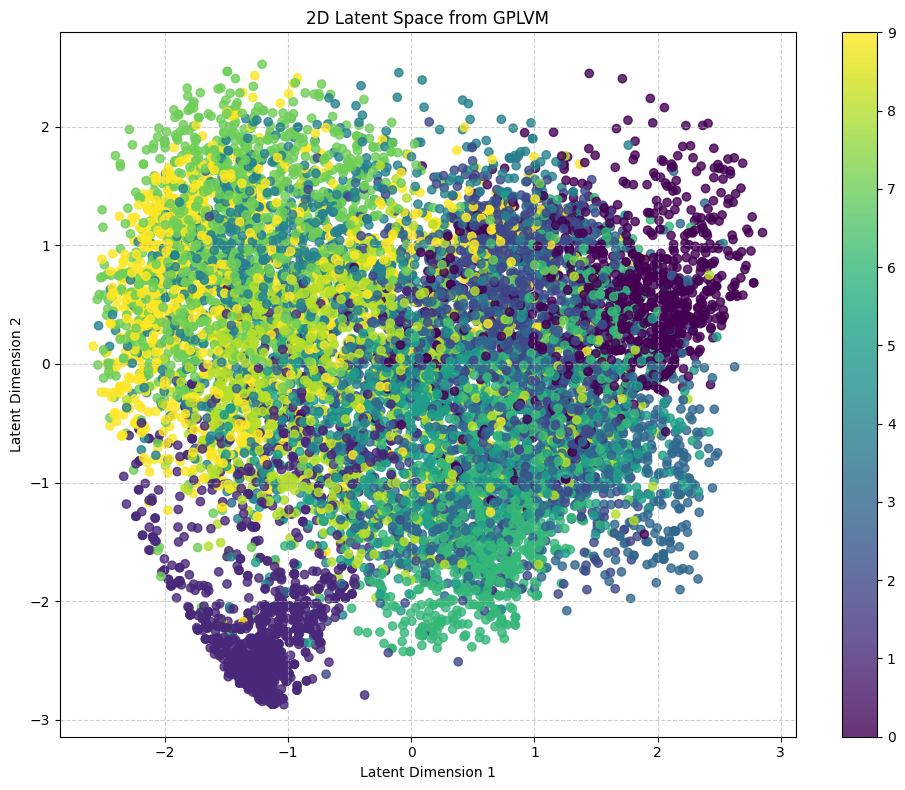

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import gpytorch
from sklearn.model_selection import train_test_split

# First, let's define a simple VAE
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)  # mu
        self.fc22 = nn.Linear(hidden_dim, latent_dim)  # log_var
        
        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))
    
    def forward(self, x):
        mu, log_var = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var, z

# Define the loss function for VAE
def loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + KLD

# Now, let's define our GPLVM model using GPyTorch
# Base exact GP model for GPLVM
class ExactGPLVMModel(gpytorch.models.ExactGP):
    def __init__(self, X, Y, kernel='rbf'):
        # X is the latent variable (2D in our case)
        # Y is a single dimension of observed data
        likelihood = gpytorch.likelihoods.GaussianLikelihood()
        super(ExactGPLVMModel, self).__init__(X, Y, likelihood)
        
        # Store input dimension for validation
        self.input_dim = X.shape[1]
        
        self.mean_module = gpytorch.means.ZeroMean()
        
        if kernel == 'rbf':
            base_kernel = gpytorch.kernels.RBFKernel(ard_num_dims=self.input_dim)
            self.covar_module = gpytorch.kernels.ScaleKernel(base_kernel)
        elif kernel == 'matern':
            base_kernel = gpytorch.kernels.MaternKernel(ard_num_dims=self.input_dim)
            self.covar_module = gpytorch.kernels.ScaleKernel(base_kernel)
        else:
            raise ValueError("Kernel must be 'rbf' or 'matern'")
            
    def forward(self, x):
        # Ensure input has the right dimensionality
        if x.shape[1] != self.input_dim:
            raise ValueError(f"Expected input dimension {self.input_dim}, got {x.shape[1]}")
            
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Sparse GP model for GPLVM (for larger datasets)
class SparseGPLVMModel(gpytorch.models.ApproximateGP):
    def __init__(self, X, Y, inducing_points, kernel='rbf'):
        # Store input dimension for validation
        self.input_dim = X.shape[1]
        
        # Use a variational strategy for sparse approximation
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self, inducing_points, variational_distribution, learn_inducing_locations=True
        )
        super(SparseGPLVMModel, self).__init__(variational_strategy)
        
        self.mean_module = gpytorch.means.ZeroMean()
        
        if kernel == 'rbf':
            base_kernel = gpytorch.kernels.RBFKernel(ard_num_dims=self.input_dim)
            self.covar_module = gpytorch.kernels.ScaleKernel(base_kernel)
        elif kernel == 'matern':
            base_kernel = gpytorch.kernels.MaternKernel(ard_num_dims=self.input_dim)
            self.covar_module = gpytorch.kernels.ScaleKernel(base_kernel)
        else:
            raise ValueError("Kernel must be 'rbf' or 'matern'")
            
    def forward(self, x):
        # Ensure input has the right dimensionality
        if x.shape[1] != self.input_dim:
            raise ValueError(f"Expected input dimension {self.input_dim}, got {x.shape[1]}")
            
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
        
# Multi-output GPLVM with independent models for each dimension
class GPLVM:
    def __init__(self, X, Y, kernel='rbf', sparse=False, inducing_points=None):
        self.X = X
        self.Y = Y
        self.output_dims = Y.shape[1]
        self.models = []
        self.likelihoods = []
        self.sparse = sparse
        self.latent_dim = X.shape[1]  # Store the latent dimension
        
        # Create a separate GP model for each output dimension
        for i in range(self.output_dims):
            if sparse:
                # Use sparse approximation
                if inducing_points is None:
                    raise ValueError("Must provide inducing points for sparse GPLVM")
                
                model = SparseGPLVMModel(X, Y[:, i], inducing_points, kernel)
                likelihood = gpytorch.likelihoods.GaussianLikelihood()
                self.models.append(model)
                self.likelihoods.append(likelihood)
            else:
                # Use exact GP
                model = ExactGPLVMModel(X, Y[:, i], kernel)
                self.models.append(model)
                self.likelihoods.append(model.likelihood)
    
    def parameters(self):
        """Return parameters of all models"""
        params = []
        for model in self.models:
            params.extend(list(model.parameters()))
        for likelihood in self.likelihoods:
            params.extend(list(likelihood.parameters()))
        return params
        
    def to(self, device):
        """Move all models and likelihoods to device"""
        for i in range(len(self.models)):
            self.models[i] = self.models[i].to(device)
            self.likelihoods[i] = self.likelihoods[i].to(device)
        return self
        
    def train(self):
        for model in self.models:
            model.train()
        for likelihood in self.likelihoods:
            likelihood.train()
            
    def eval(self):
        for model in self.models:
            model.eval()
        for likelihood in self.likelihoods:
            likelihood.eval()

# Function to train the VAE model
def train_vae(model, data_loader, epochs=10, device='cpu'):
    optimizer = Adam(model.parameters(), lr=1e-3)
    model.train()
    
    for epoch in range(epochs):
        train_loss = 0
        for batch_idx, (data, _) in enumerate(data_loader):
            data = data.to(device)
            optimizer.zero_grad()
            
            recon_batch, mu, log_var, _ = model(data)
            loss = loss_function(recon_batch, data, mu, log_var)
            
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
            
        print(f'Epoch: {epoch}, Loss: {train_loss / len(data_loader.dataset):.4f}')
    
    return model

# Function to extract embeddings from trained VAE
def extract_vae_embeddings(vae_model, data_loader, device='cpu'):
    vae_model.eval()
    embeddings = []
    
    with torch.no_grad():
        for data, _ in data_loader:
            data = data.to(device)
            _, mu, _, _ = vae_model(data)
            embeddings.append(mu.cpu().numpy())
    
    return np.vstack(embeddings)

# Initialize and optimize GPLVM
def train_gplvm(Y, latent_dim=2, learning_rate=0.01, iterations=1000, 
                batch_size=5, patience=5, improvement_threshold=0.01,
                X_init=None):
    """
    Train a GPLVM model with efficiency improvements:
    1. Dimension batching - process multiple output dimensions in each iteration
    2. Early stopping - stop training when loss plateaus
    3. Learning rate scheduling - reduce learning rate when progress slows
    4. Smart initialization - option to use PCA or other initialization
    5. Sparse approximation for larger datasets
    
    Args:
        Y: VAE embeddings (n_samples × n_dimensions)
        latent_dim: Dimensionality of the latent space
        learning_rate: Initial learning rate
        iterations: Maximum number of iterations
        batch_size: Number of output dimensions to process in each batch
        patience: Number of iterations to wait for improvement before early stopping
        improvement_threshold: Minimum relative improvement to reset patience counter
        X_init: Optional initialization for latent points (e.g., from PCA)
    """
    # Initialize latent points (randomly or from provided initialization)
    n_samples = Y.shape[0]
    output_dim = Y.shape[1]
    
    print(f"Input data shape: {Y.shape} (samples × dimensions)")
    print(f"Target latent dimension: {latent_dim}")
    
    if X_init is not None:
        X = X_init.clone().requires_grad_(True)
        print(f"Using provided initialization with shape: {X.shape}")
    else:
        X = torch.randn(n_samples, latent_dim, requires_grad=True)
        print(f"Using random initialization with shape: {X.shape}")
    
    Y_tensor = torch.tensor(Y, dtype=torch.float32)
    
    # Use sparse GP approximation for larger datasets
    use_sparse = n_samples > 500
    inducing_points = None
    
    if use_sparse:
        # If using sparse approximation, select inducing points
        # We'll initialize with K-means centers
        from sklearn.cluster import KMeans
        n_inducing = min(100, n_samples // 5)  # Rule of thumb: 100 or 20% of data
        
        print(f"Using sparse approximation with {n_inducing} inducing points")
        # For inducing points, we need to cluster in the output space (Y)
        # and then initialize them in the same space
        kmeans = KMeans(n_clusters=n_inducing, random_state=0, n_init=3)
        kmeans.fit(Y)
        
        # The inducing points need to be in the latent space (X) dimensionality
        if latent_dim == 2:  # Simple case for 2D latent space
            inducing_X = torch.zeros((n_inducing, latent_dim), dtype=torch.float32)
            # Create a grid of points in 2D space
            grid_size = int(np.ceil(np.sqrt(n_inducing)))
            for i in range(n_inducing):
                row = i // grid_size
                col = i % grid_size
                inducing_X[i, 0] = -1.0 + 2.0 * (col / (grid_size - 1)) if grid_size > 1 else 0
                inducing_X[i, 1] = -1.0 + 2.0 * (row / (grid_size - 1)) if grid_size > 1 else 0
            inducing_points = inducing_X
        else:
            # For higher dimensions, initialize with PCA
            from sklearn.decomposition import PCA
            pca = PCA(n_components=latent_dim)
            # Fit PCA on the cluster centers
            inducing_points = torch.tensor(
                pca.fit_transform(kmeans.cluster_centers_), 
                dtype=torch.float32
            )
        
        print(f"Inducing points shape: {inducing_points.shape}")
    
    # Define GPLVM model with multiple output dimensions
    model = GPLVM(X, Y_tensor, sparse=use_sparse, inducing_points=inducing_points)
    
    # Use the adam optimizer with weight decay (L2 regularization)
    optimizer = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': [X], 'lr': learning_rate * 2}  # Higher learning rate for latent points
    ], lr=learning_rate, weight_decay=1e-4)
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=patience//2, verbose=True
    )
    
    # "Loss" for GPs - the marginal log likelihood
    mlls = [gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihoods[i], model.models[i]) 
            if not use_sparse else 
            gpytorch.mlls.VariationalELBO(model.likelihoods[i], model.models[i], num_data=n_samples)
            for i in range(model.output_dims)]
    
    # Training loop
    model.train()
    
    # For early stopping
    best_loss = float('inf')
    no_improvement_count = 0
    best_X = X.clone().detach()
    
    # Prepare dimension batches
    output_dims = list(range(model.output_dims))
    
    # Use CUDA if available for faster computation
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X = X.to(device)
    Y_tensor = Y_tensor.to(device)
    model.to(device)
    
    print(f"Training GPLVM on {device}...")
    
    for i in range(iterations):
        # Shuffle dimension ordering each epoch for better convergence
        np.random.shuffle(output_dims)
        batches = [output_dims[j:j+batch_size] for j in range(0, len(output_dims), batch_size)]
        
        epoch_loss = 0
        
        for batch_dims in batches:
            optimizer.zero_grad()
            
            # Compute loss for this batch of dimensions
            batch_loss = 0
            for j in batch_dims:
                try:
                    output = model.models[j](X)
                    batch_loss -= mlls[j](output, Y_tensor[:, j])
                except Exception as e:
                    print(f"Error in dimension {j}: {e}")
                    print(f"X shape: {X.shape}")
                    print(f"Y shape: {Y_tensor[:, j].shape}")
                    print(f"Model input dim: {model.latent_dim}")
                    raise
            
            batch_loss.backward()
            optimizer.step()
            epoch_loss += batch_loss.item()
        
        # Track progress
        if (i+1) % 10 == 0:
            print(f'Iteration {i+1}/{iterations} - Loss: {epoch_loss:.4f}')
        
        # Learning rate scheduling
        scheduler.step(epoch_loss)
        
        # Early stopping check
        if epoch_loss < best_loss * (1 - improvement_threshold):
            best_loss = epoch_loss
            no_improvement_count = 0
            best_X = X.clone().detach()
        else:
            no_improvement_count += 1
            
        if no_improvement_count >= patience:
            print(f"Early stopping at iteration {i+1} due to no improvement")
            break
    
    # Return best optimized latent points
    return best_X.cpu().numpy()

# Main function to run the complete pipeline
def vae_gplvm_reduction(data, batch_size=128, vae_epochs=10, gplvm_iterations=1000, 
                       max_gplvm_samples=1000, use_pca_init=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Prepare the data
    x_train, x_test = train_test_split(data, test_size=0.2, random_state=42)
    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(x_train), torch.zeros(len(x_train))),
        batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        TensorDataset(torch.FloatTensor(x_test), torch.zeros(len(x_test))),
        batch_size=batch_size, shuffle=False
    )
    
    # Define and train VAE
    input_dim = data.shape[1]
    vae = VAE(input_dim=input_dim, hidden_dim=400, latent_dim=20).to(device)
    vae = train_vae(vae, train_loader, epochs=vae_epochs, device=device)
    
    # Extract embeddings from VAE
    embeddings = extract_vae_embeddings(vae, test_loader, device=device)
    
    # Subsample for GPLVM if needed (for efficiency)
    if embeddings.shape[0] > max_gplvm_samples:
        print(f"Subsampling {max_gplvm_samples} points from {embeddings.shape[0]} for GPLVM training")
        indices = np.random.choice(embeddings.shape[0], max_gplvm_samples, replace=False)
        embeddings_subset = embeddings[indices]
    else:
        embeddings_subset = embeddings
    
    # PCA initialization for faster convergence (optional)
    if use_pca_init:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        latent_init = pca.fit_transform(embeddings_subset)
        print("Using PCA initialization for GPLVM")
        
        # Train GPLVM on VAE embeddings with PCA initialization
        latent_2d_subset = train_gplvm(
            embeddings_subset, 
            latent_dim=2, 
            iterations=gplvm_iterations,
            X_init=torch.tensor(latent_init, dtype=torch.float32)
        )
    else:
        # Train GPLVM on VAE embeddings and reduce to 2D
        latent_2d_subset = train_gplvm(
            embeddings_subset, 
            latent_dim=2, 
            iterations=gplvm_iterations
        )
    
    # If we subsampled, we need to map the remaining points
    if embeddings.shape[0] > max_gplvm_samples:
        # Train a simple model to map from VAE embeddings to GPLVM latent space
        from sklearn.neighbors import KNeighborsRegressor
        knn = KNeighborsRegressor(n_neighbors=5)
        knn.fit(embeddings_subset, latent_2d_subset)
        
        # Map all points
        latent_2d = knn.predict(embeddings)
    else:
        latent_2d = latent_2d_subset
    
    return latent_2d, vae

# Visualization function
def visualize_latent_space(latent_points, labels=None):
    plt.figure(figsize=(10, 8))
    
    if labels is not None:
        # Handle case where labels and latent_points have different lengths
        if len(labels) != len(latent_points):
            print(f"Warning: Labels ({len(labels)}) and latent points ({len(latent_points)}) have different lengths")
            print("Using only the first matching subset of labels")
            
            # Use only the first n labels where n is the length of latent_points
            labels_subset = labels[:len(latent_points)] if len(labels) > len(latent_points) else labels
            
            scatter = plt.scatter(latent_points[:, 0], latent_points[:, 1], c=labels_subset, cmap='viridis', alpha=0.8)
        else:
            scatter = plt.scatter(latent_points[:, 0], latent_points[:, 1], c=labels, cmap='viridis', alpha=0.8)
            
        plt.colorbar(scatter)
    else:
        plt.scatter(latent_points[:, 0], latent_points[:, 1], alpha=0.8)
    
    plt.title('2D Latent Space from GPLVM')
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Example usage with MNIST
if __name__ == "__main__":
    # If you have torchvision installed
    from torchvision import datasets, transforms
    
    # Load MNIST dataset
    mnist_data = datasets.MNIST('./data', train=True, download=True,
                             transform=transforms.ToTensor())
    
    # Prepare data
    x = mnist_data.data.float() / 255.0
    x = x.reshape(x.shape[0], -1).numpy()  # Flatten images
    y = mnist_data.targets.numpy()  # Labels for visualization
    
    print(f"Data shape: {x.shape}, Labels shape: {y.shape}")
    
    # Run the pipeline
    latent_2d, vae_model = vae_gplvm_reduction(x, vae_epochs=5, gplvm_iterations=500)
    
    print(f"Latent space shape: {latent_2d.shape}")
    
    # Since we're using train/test split, we need to use only the test labels
    # that correspond to our latent points
    test_size = 0.2
    _, test_indices = train_test_split(
        np.arange(len(y)), test_size=test_size, random_state=42
    )
    test_labels = y[test_indices]
    
    print(f"Test labels shape: {test_labels.shape}")
    print(f"Number of visualized points: {len(latent_2d)}")
    
    # Make sure labels match latent points
    if len(test_labels) > len(latent_2d):
        test_labels = test_labels[:len(latent_2d)]
    elif len(test_labels) < len(latent_2d):
        latent_2d = latent_2d[:len(test_labels)]
        
    # Visualize results
    visualize_latent_space(latent_2d, test_labels)